## Import:
Import the following functions/ classes:

In [1]:
from pathlib import Path

from gofher.gofher_parameters import read_gofher_parameters_from_csv
from gofher.galaxy import Galaxy
from gofher.sparcfire import gofher_params_from_sparcfire_csv

## Paths:
Set the specific paths to the fits data and galaxy.csv

We will also create helper functions to get the full path for the fits/ galaxy.csv

In [2]:
#IMPORTANT: Make sure these folder/file names reflect test file structure:
TEST_GALAXY_DIR = "NGC2347_SDSS_psf4_background_256"
TEST_SPARCFIRE_DIR = "sparcfire_r_band_output"
TEST_FITS_DIR = "fits"
TEST_CSV_FILE_NAME = "NGC2347_r.csv"

def _get_test_csv_path() -> str:
    p = Path("..").resolve()
    return str(p.joinpath("tests", "data", TEST_GALAXY_DIR, TEST_SPARCFIRE_DIR, TEST_CSV_FILE_NAME))

def _get_test_fits_path(the_band) -> str:
    """Helper function to get path to test fits file"""
    fits_file_name = f"NGC2347_{the_band}.fits"

    p = Path("..").resolve()
    return str(p.joinpath("tests", "data", TEST_GALAXY_DIR, TEST_FITS_DIR, fits_file_name))

## Set the Run specific parameters:
* `bluer_to_redder_bands` is a list of the fits wavebands ordered bluest light first to reddest light last
* `sparcfire_bulge_disk_f` is the number in range `[0,1]` that specifies the scale of the galaxy ellipse mask to use. When `sparcfire_bulge_disk_f=0` the ellipse uses the bulge major axis, when `sparcfire_bulge_disk_f=1` the ellipse uses the disk major axis, otherwise interpolates between bulge and disk major axis

In [3]:
bluer_to_redder_bands = ['g','r','i','z']
sparcfire_bulge_disk_f = 0.5

## Running Gofher with `area_to_consider`:
`area_to_consider` is a boolean numpy array that specifies which pixels can be considered by gofher. The only requirements are:
1) It must be a numpy array of boolean variables.
2) It must be the same shape as the fits files used.
3) It must have at least one True pixel that lies on the intersection of `ellipse_mask and valid_pixel_mask and and pos_mask` and atleast one True pixel that lies on the intersection of `ellipse_mask and valid_pixel_mask and neg_mask`*

* Note in this implementation: valid_pixel_mask is shared acrossed all bands passed into run(), so if one waveband has a NAN/inf value, it will be False in valid_pixel_mask

## Why would I use `area_to_consider`?:
Good question, well if you want to only focus on a subset on the image you can use `area_to_consider`.

For example, let's say you only care about analyzing the redness gradient near the minox axis of the galaxy's disk, you can use `area_to_consider`. See the example below:

sweep of 1.571 rads from minor axis


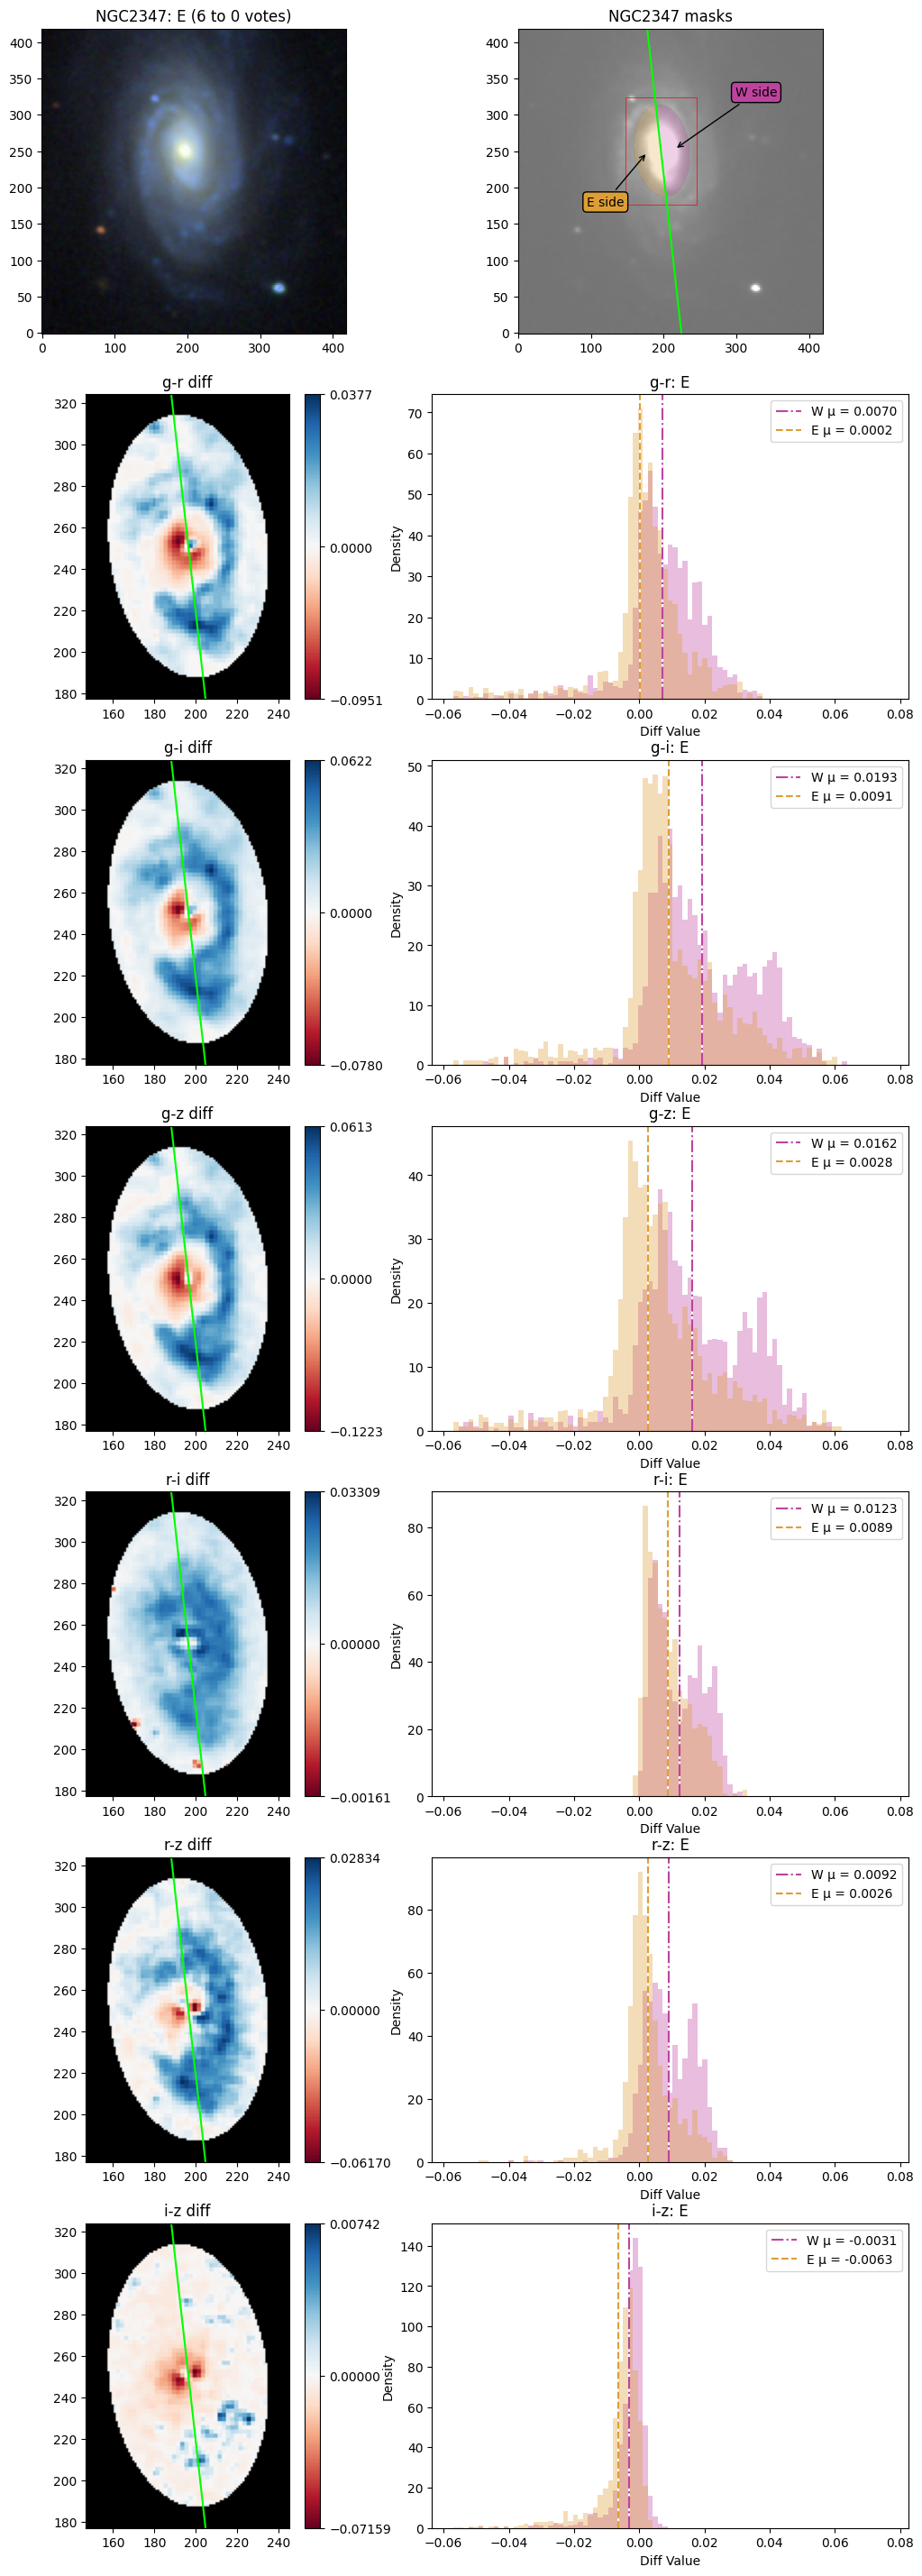

sweep of 1.047 rads from minor axis


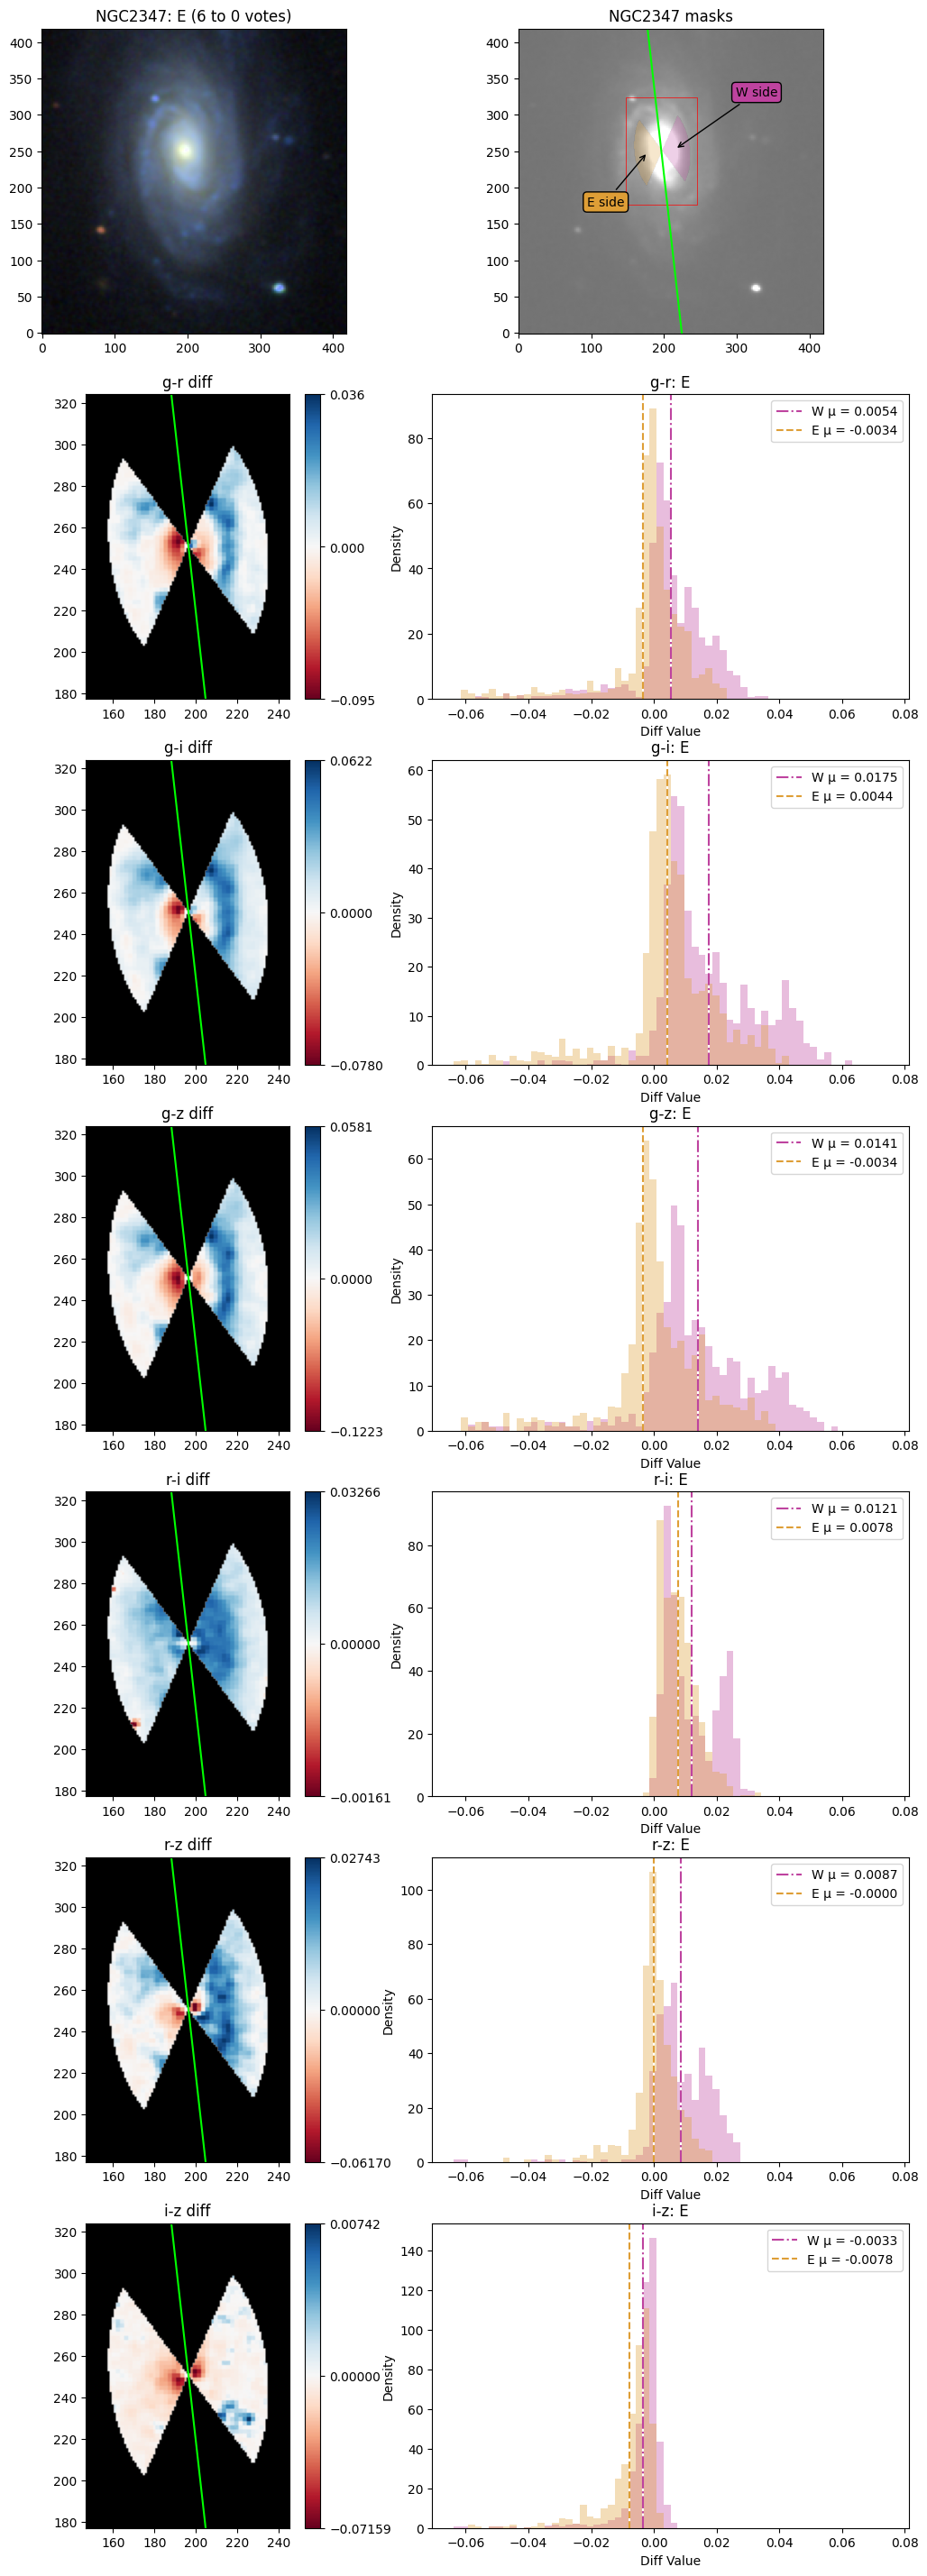

sweep of 0.785 rads from minor axis


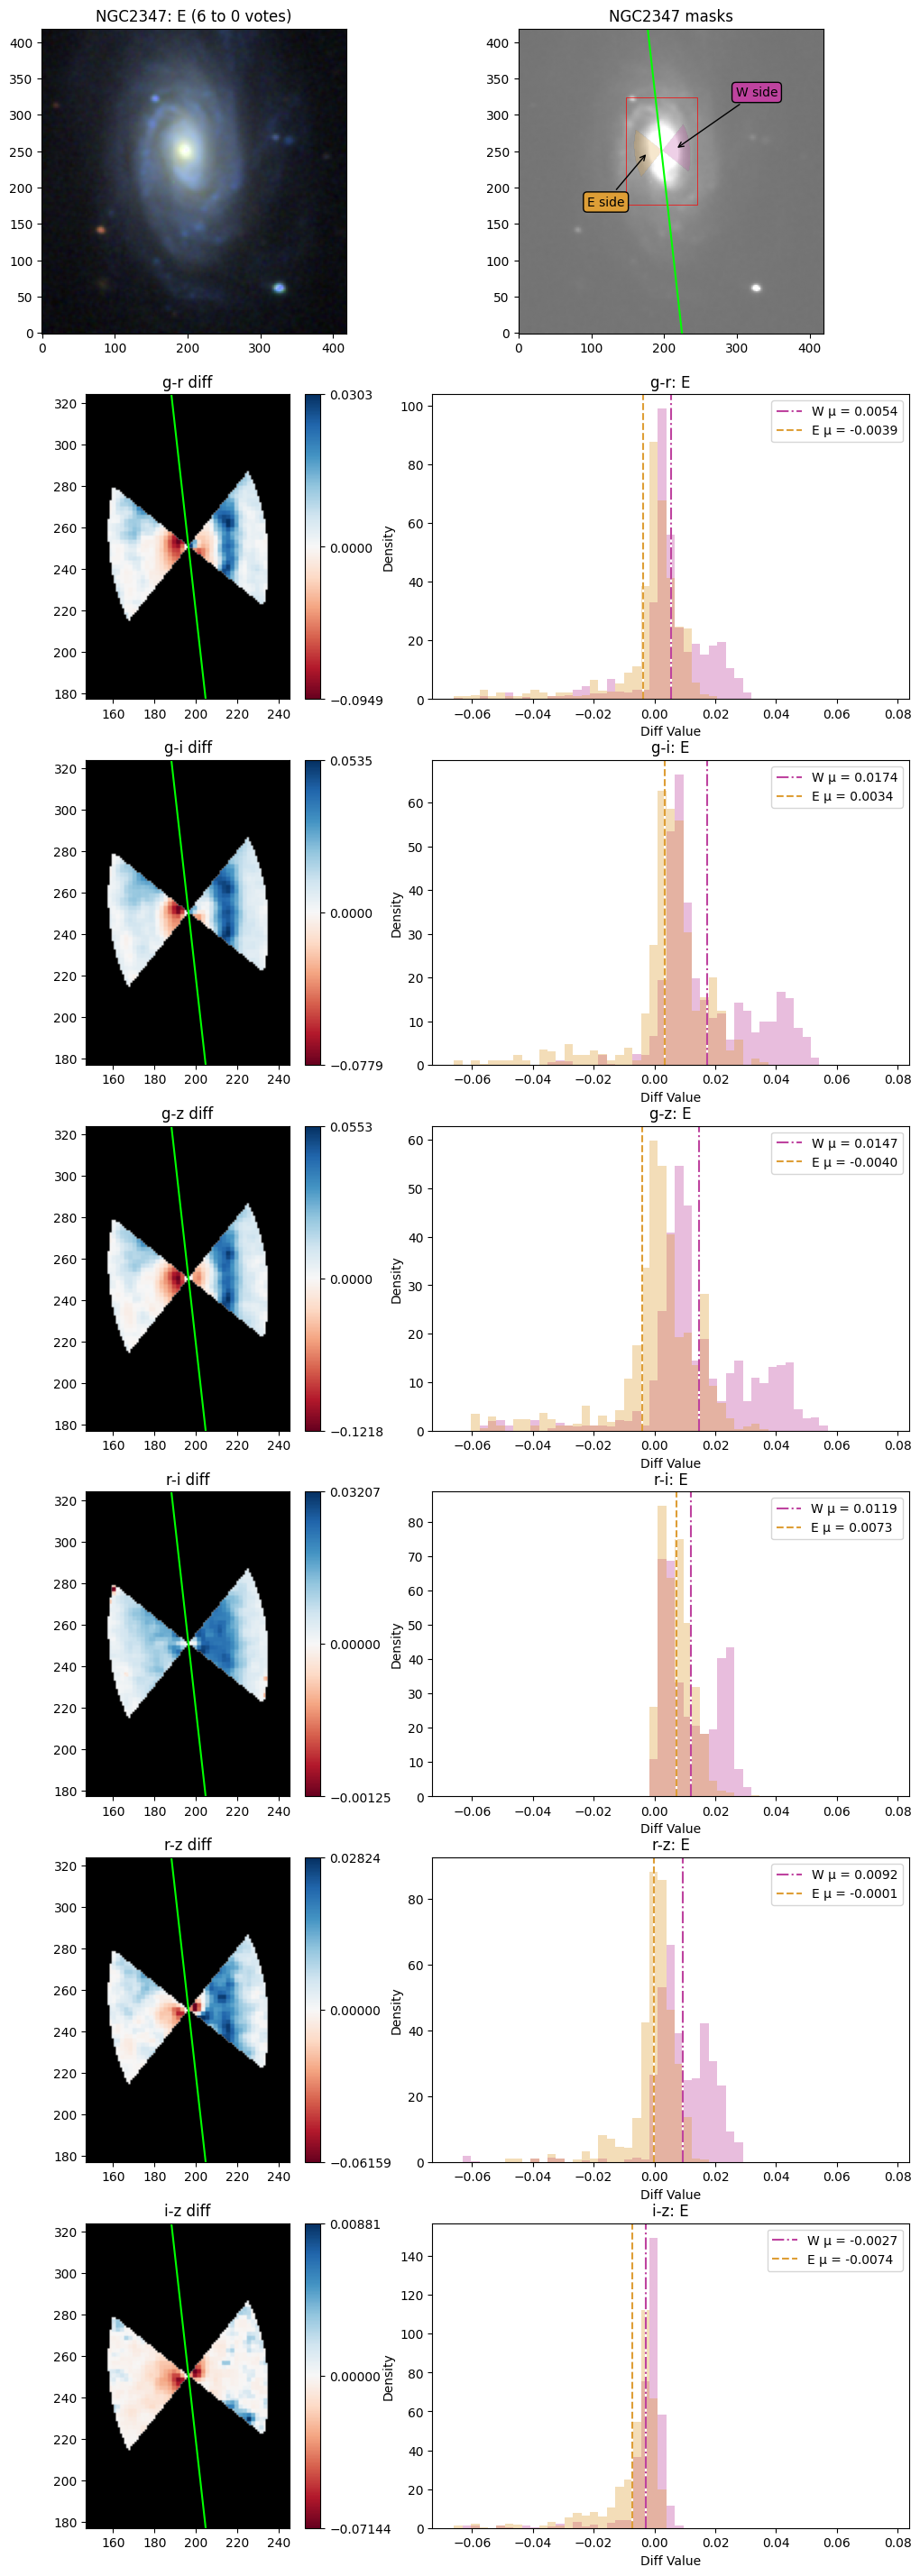

sweep of 0.628 rads from minor axis


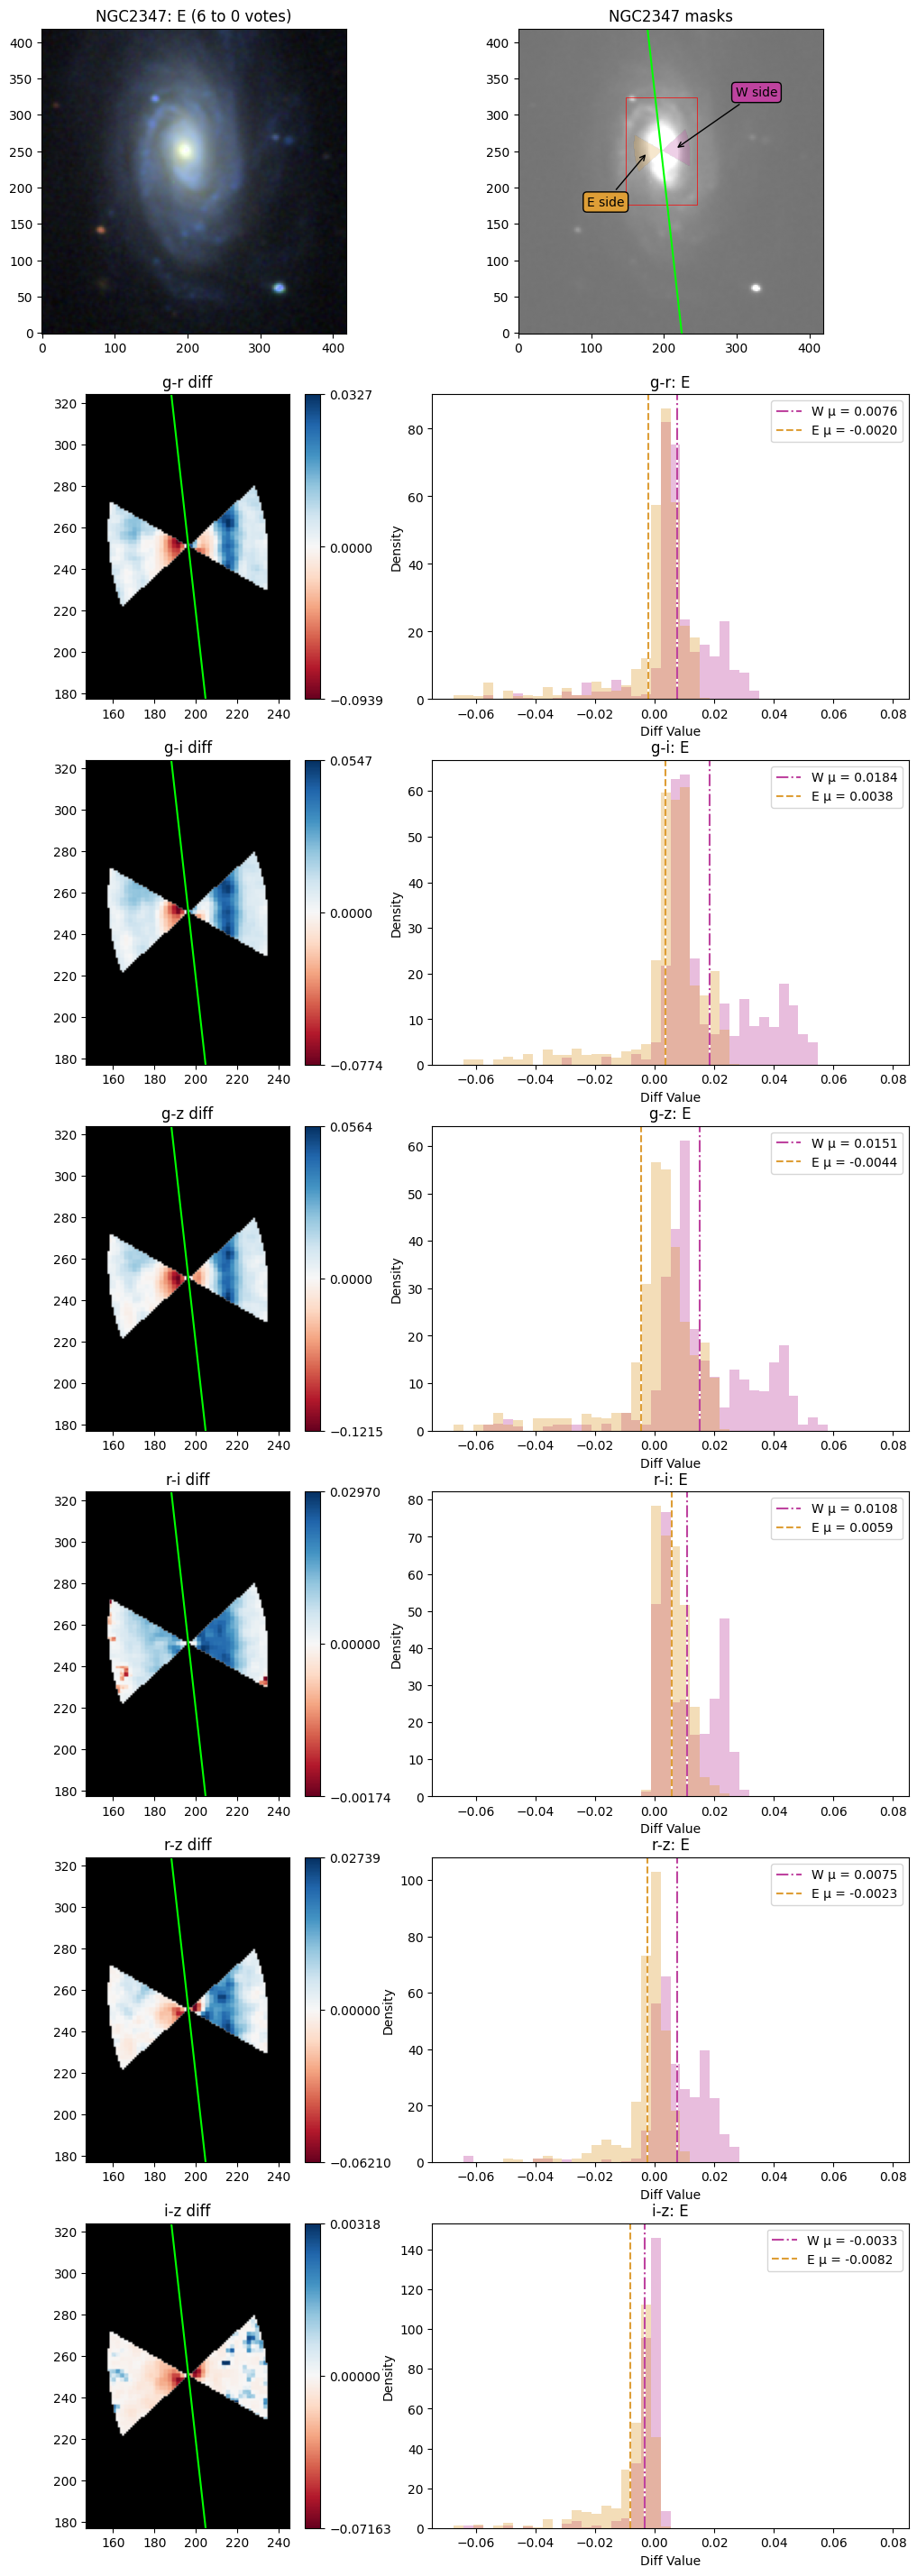

sweep of 0.524 rads from minor axis


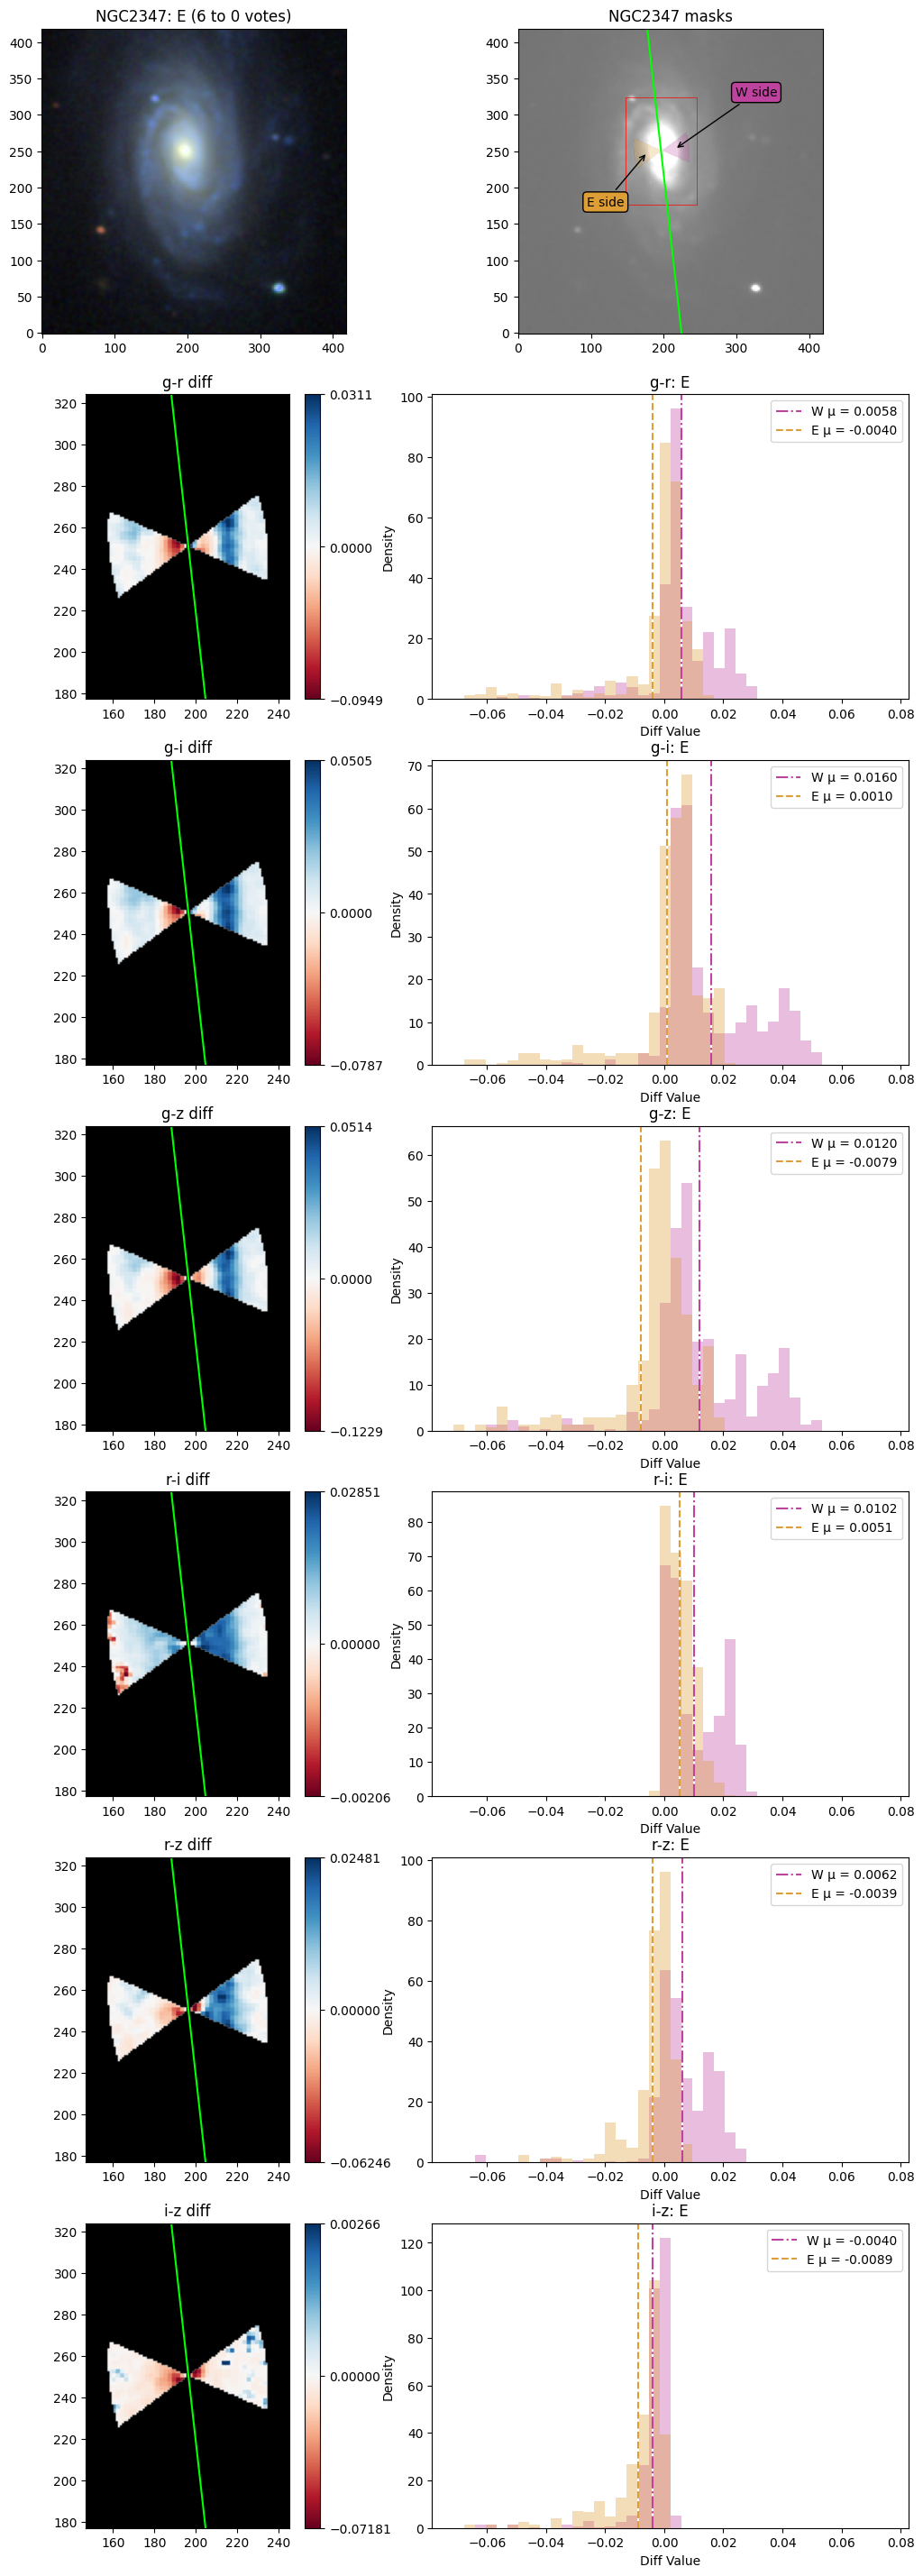

sweep of 0.449 rads from minor axis


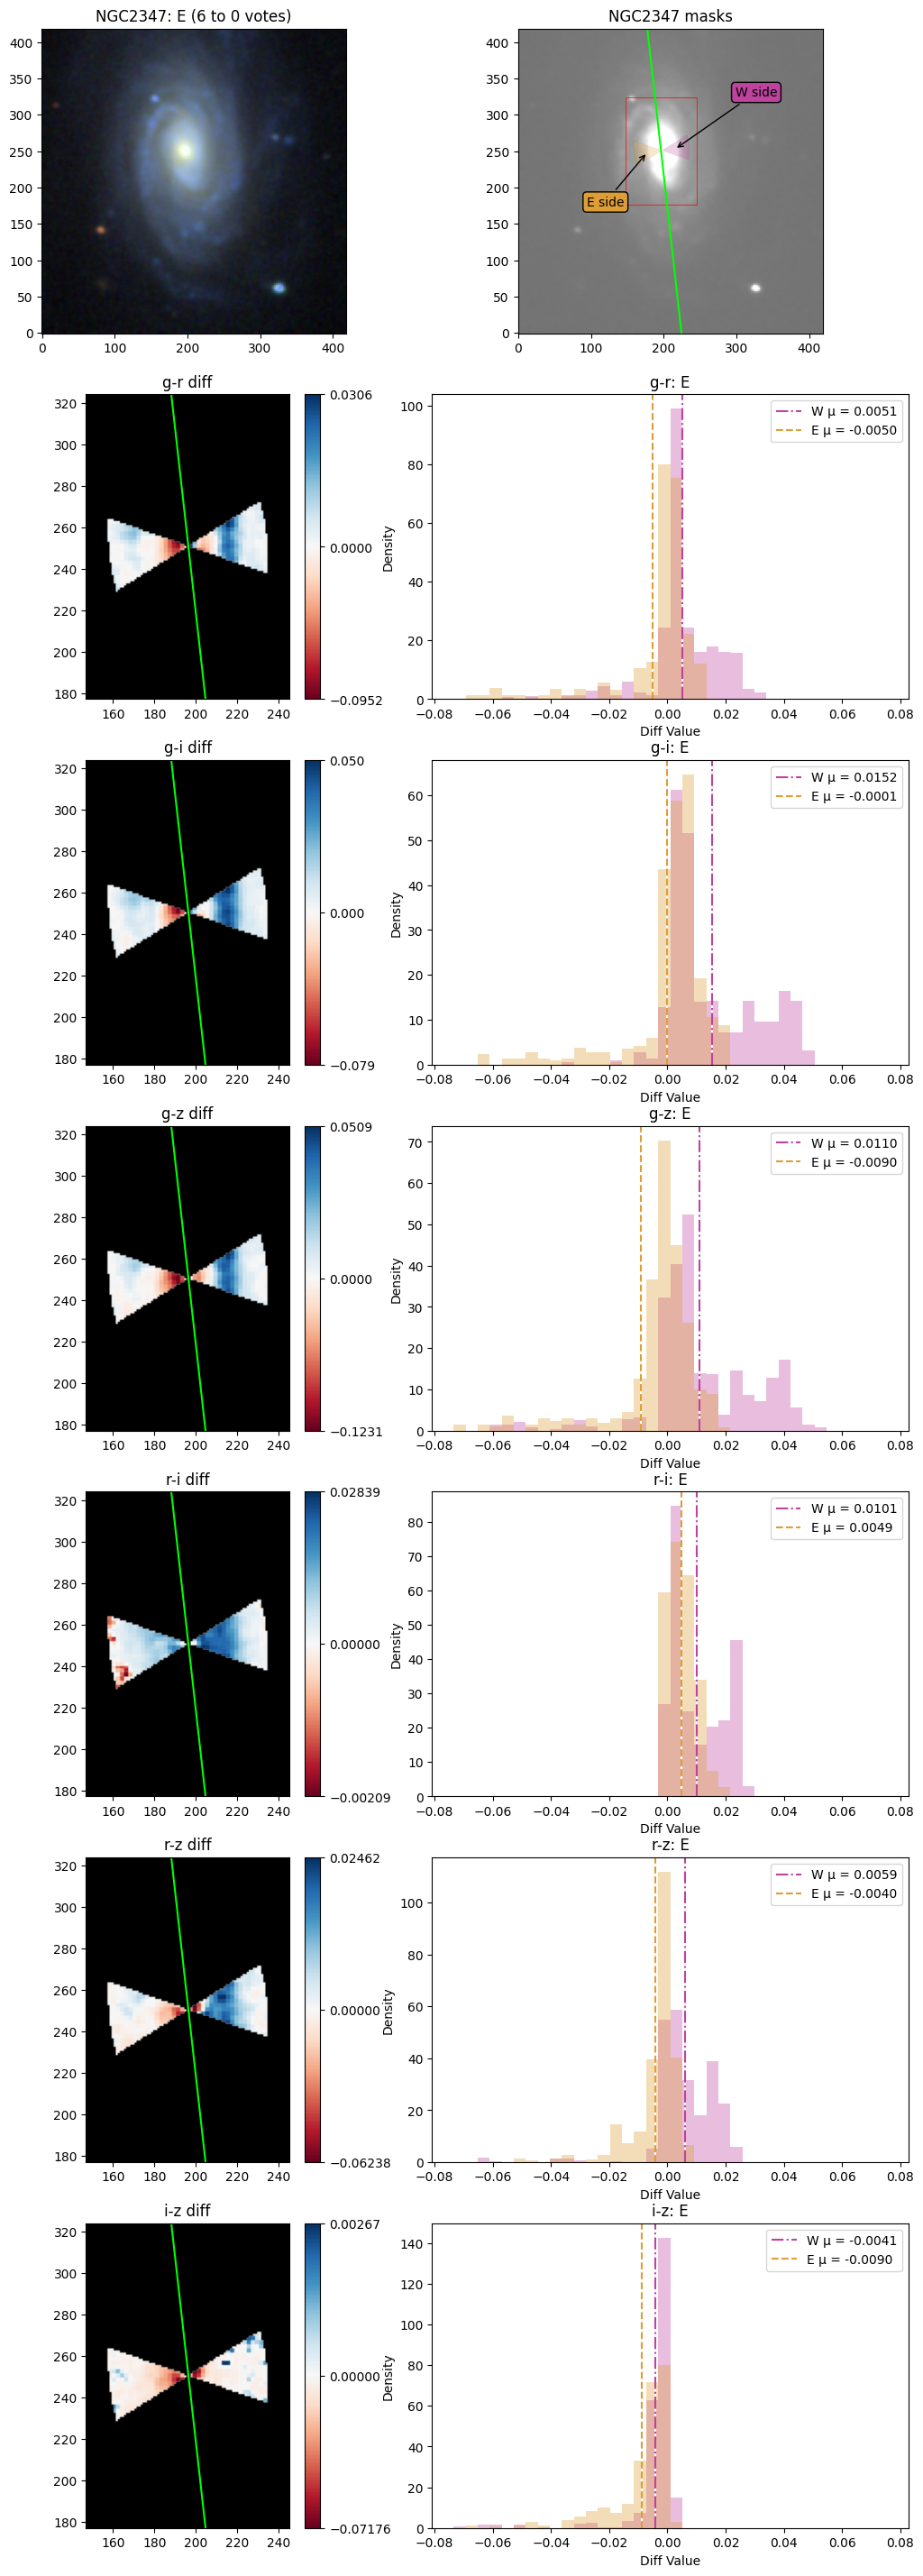

In [4]:
import numpy as np

# Get the GOFHER parameters from the SparcFiRe galaxy.csv:
gofher_param = gofher_params_from_sparcfire_csv(_get_test_csv_path())[0]

# Create a Galaxy and add all wavebands to it:
the_galaxy = Galaxy(gofher_param)

for band in bluer_to_redder_bands:
    the_galaxy.construct_galaxy_band_from_fits(band,_get_test_fits_path(band))

# Important: If you using create_near_minor_axis using the sparcfire gofher parameter
#   this must be called prior calling create_near_minor_axis():
the_galaxy.gofher_params.calculate_from_sparcfire(sparcfire_bulge_disk_f)

# Iterate through a range of sweeps from minor axis to compare GOFHER's output:
for denominator in range(2,8):
    sweep = np.pi/ denominator
    print(f"sweep of {sweep:.3f} rads from minor axis")

    area_to_consider = the_galaxy.gofher_params.create_near_minor_axis_mask(sweep)

    # Run GOFHER on the galaxy:
    the_galaxy.run(bluer_to_redder_bands=bluer_to_redder_bands,
                sparcfire_bulge_disk_f=sparcfire_bulge_disk_f,
                area_to_consider=area_to_consider,
                fail_silently_on_missing_band=False)

    # Plot a figure visualization GOFHER's output:
    the_galaxy.plot_figure()